# MOC-Imbalance — a quantitative teardown 🔬
### A closing-pressure displacement proxy · an `overnight ~ disp` reversal regression · a HAC *t* + placebo randomization null · the rebalance-day subset · the fade net of costs · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the closing-auction-imbalance reversal claim as a single regression — the overnight gap on a displacement proxy for end-of-day pressure — and confront it with **autocorrelation-robust inference**, a **placebo null**, the **rebalance-day subset** (the believers' strongest case), and a **cost-aware fade**. The decisive object is not the slope's sign (it is negative, as the lore says) but its **magnitude relative to its HAC standard error and to the bid-ask spread**.

> ⚠️ **Data + proxy note.** A true MOC order-imbalance feed (NYSE Order Imbalances / Nasdaq NOII) is a paid product; we build a transparent **proxy** — the signed intraday displacement `(close−open)/(high−low)`. It is coarse and, via the open's bid-ask bounce, can only **over**-state reversal (both named on the Signal axis). Real data: yfinance daily OHLC, SPY/QQQ/IWM, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from moc_imbalance import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real OHLC cache present:", HAVE_REAL,
      "| panel rows:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-17', 'days': 16194, 'years': 21.5, 'n_rebal': 252, 'all': (16194, -0.00017, -1.48, 0.076, -0.011, 50.5), 'rebal': (252, -0.00044, -0.48, 0.325, -0.029, 52.2), 'spy': (5398, -0.00027, -1.54, 0.072, -0.02, 50.9), 'qqq': (5398, -0.00012, -0.64, 0.266, -0.009, 49.3), 'iwm': (5398, -0.00011, -0.49, 0.316, -0.007, 51.3), 'sharpe': 0.037, 'costs': [(0.0, 0.18, 0.46), (1.0, -0.82, -2.04), (2.0, -1.82, -4.48)], 'syn': [(0.0, 4000, -3e-05, -0.003, -0.2, 0.4155, 51.1), (0.1, 4000, -0.00111, -0.13, -8.1, 0.0, 55.6)]}


real OHLC cache present: True | panel rows: 16194


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | reversal slope **b = -0.00017**, HAC **t = -1.48** (placebo **p = 0.076**), corr **-0.011** — direction-correct but **fails t ≥ 2**, and the rebalance-day *t* is **-0.48** (weaker, not stronger). |
| **Tradability** | `MIRAGE` | gross fade **+0.18 bps**/trade (Sharpe ≈ 0.04); at **1 bp** cost **-0.82 bps**, at 2 bps **-1.82 bps** (-4.5%/yr). The reversal is inside the spread. |
| **Free lunch?** | `BUSTED` | win-rate **50.5%** ≈ 50%; the effect *evaporates* on rebalance days. Real-as-microstructure, empty-as-alpha. |

> 💡 In plain words: the imbalance really does reverse a touch overnight — because short-horizon moves wobble back, and the proxy double-counts the open's bid-ask bounce. Strip the spread and ~zero edge is left, concentrated *away* from where a real imbalance lives.

## 1 · The claim, steelmanned

Let $d_t$ be the signed displacement $(c_t-o_t)/(h_t-l_t)\in[-1,1]$ (the closing-pressure proxy) and $g_{t+1} = o_{t+1}/c_t - 1$ the overnight gap. The reversal claim is a sign on the slope of

$$g_{t+1} = a + b\,d_t + \varepsilon_{t+1},\qquad H_1:\ b < 0.$$

- **H₁ (reversal exists).** $b<0$ robustly — a push into the close leans back overnight.
- **H₂ (it's deployable).** The fade $-\operatorname{sign}(d_t)\cdot g_{t+1}$ earns more than the round-trip spread.
- **H₃ (rebalance concentration).** $|b|$ and $|t|$ are **larger** on index-rebalance days, where real MOC imbalances are largest.

We find **H₁ not rejected but not supported** ($b<0$ but HAC $t=-1.48$), **H₂ rejected** (gross +0.18 bps, negative after 1 bp), **H₃ rejected** (the rebalance-day $t$ is $-0.48$ — *weaker*). The trade is true exactly where it's uninformative (a sub-spread wobble) and false exactly where it would pay (a *concentrated, tradable* imbalance edge).

## 2 · So what? — what rides on each answer

The teardown is one slope judged by its **HAC standard error** and by the **bid-ask spread**.

$$\hat b = \frac{\sum (d_t-\bar d)(g_{t+1}-\bar g)}{\sum (d_t-\bar d)^2},\qquad t_{\text{HAC}} = \frac{\hat b}{\operatorname{SE}_{\text{NW}}(\hat b)}.$$

Overnight gaps are serially correlated and heteroskedastic, so an OLS SE understates the noise — we use **Newey-West**. But even a *significant* $\hat b$ would not be an edge: the fade pays the spread twice, and the implied per-trade edge $|\hat b|\cdot\mathbb{E}|d|$ is a fraction of a basis point. The right second lens is therefore not statistical at all — it is **economic**: is the gross edge larger than one crossing of the spread? It is not.

## 3 · How we'd know — the protocol

- **Pressure proxy.** $d_t=(c_t-o_t)/(h_t-l_t)$ clipped to $[-1,1]$, from yfinance daily OHLC for SPY/QQQ/IWM (2005-01-03→2026-06-17, 16,194 ticker-days). Explicit **proxy** for the MOC order imbalance — coarse, and bid-ask-bounce-inflated (named on the axis).
- **Target.** The overnight gap $g_{t+1}=o_{t+1}/c_t-1$. The 1-day execution lag is **structural**: entry is today's close, the gap is realised at the *next* open — no look-ahead.
- **Null #1 (HAC t).** Newey-West (5 lags) t of $\hat b$.
- **Null #2 (placebo).** 20,000 shuffles of the $d\leftrightarrow g$ pairing; $p=\Pr[\text{shuffled slope}\le\hat b]$ — the honest small-effect test.
- **Subset.** Re-run on index-rebalance days only (third Friday of quarter-end) — H₃.
- **Strategy.** Fade $-\operatorname{sign}(d_t)$, earn $g_{t+1}$; win-rate vs 50%; net of a round-trip cost.
- **Positive control.** A deterministic panel with a **planted reversal knob**: edge=0 must stay insignificant; a large knob must light up — proving the engine is unbiased *and* powerful.

## 4 · The teardown

### 4a · The slope — direction-correct, magnitude-trivial

Bin by displacement and plot the mean overnight gap with its standard error, against the fitted line. Negative-sloping (the lore's direction) but flat and noisy.

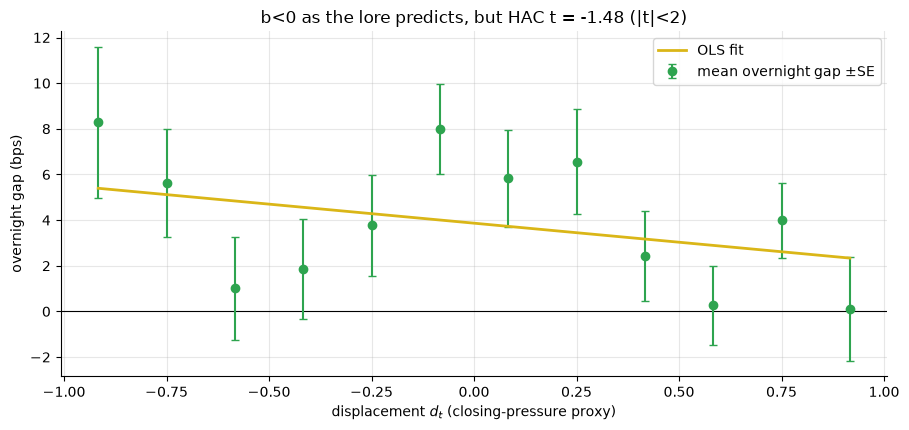

slope b=-0.00017, HAC t=-1.48, corr=-0.011  -> R^2 ~ 0.012%


In [2]:
if HAVE_REAL:
    d = PANEL['disp'].to_numpy(); o = PANEL['overnight'].to_numpy()
    s = st.summarize(PANEL); b, a = s['b'], None
    a_, b_, _ = st._ols(d, o)
    bins = np.linspace(-1, 1, 13); xc, ym, ye = [], [], []
    for i in range(len(bins)-1):
        m = (d >= bins[i]) & (d < bins[i+1])
        if m.sum() > 30:
            xc.append((bins[i]+bins[i+1])/2); ym.append(o[m].mean()*1e4)
            ye.append(o[m].std(ddof=1)/np.sqrt(m.sum())*1e4)
    xc=np.array(xc); ym=np.array(ym); ye=np.array(ye)
    tval = s['t']; line = (a_ + b_*xc)*1e4
else:
    xc = np.linspace(-0.9,0.9,12); ym = -1.7*xc + np.array([.4,-.3,.2,-.5,.1,-.2,.3,-.4,.0,-.3,.2,-.1])
    ye = np.full_like(xc, 0.8); line = (R['all'][1]*xc)*1e4; tval = R['all'][2]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.axhline(0, c='k', lw=.8)
ax.errorbar(xc, ym, yerr=ye, fmt='o', c=GREEN, capsize=3, label='mean overnight gap ±SE')
ax.plot(xc, line, c=AMBER, lw=2, label='OLS fit')
ax.set_xlabel('displacement $d_t$ (closing-pressure proxy)'); ax.set_ylabel('overnight gap (bps)')
ax.set_title(f'b<0 as the lore predicts, but HAC t = {tval:.2f} (|t|<2)'); ax.legend()
plt.tight_layout(); plt.show()
print(f'slope b={R["all"][1]:.5f}, HAC t={tval:.2f}, corr={R["all"][4]:.3f}  -> R^2 ~ {R["all"][4]**2*100:.3f}%')

> 💡 In plain words: the slope is **-0.00017** — negative, the reversal direction — but at HAC **t = -1.48** it does not clear 2, and the displacement explains **~0.01%** of the overnight gap. H₁ is **not rejected, not supported**: a correct-sign whisper buried in its own standard error.

### 4b · The placebo null sized to the effect

Shuffle the displacement↔gap pairing 20,000 times; the histogram is the null distribution of the slope. The observed slope is the green line; the *p*-value is the **left**-tail mass (more negative = more 'reversal-y').

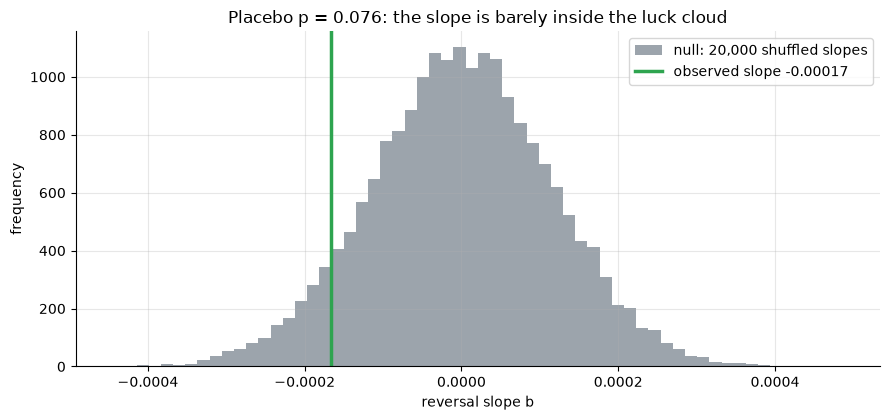

P[shuffled slope <= observed] = 0.076  (need <0.05; here ~1 in 13)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PANEL['disp'].to_numpy(), PANEL['overnight'].to_numpy(), n_draws=20000)
    obs = pl['obs_b']; pval = pl['p_value']
    d = PANEL['disp'].to_numpy(); o = PANEL['overnight'].to_numpy()
    xc = d - d.mean(); den = (xc*xc).sum(); rng = np.random.default_rng(376)
    draws = np.array([(xc*rng.permutation(o)).sum()/den for _ in range(20000)])
else:
    obs = R['all'][1]; pval = R['all'][3]
    rng = np.random.default_rng(376); draws = rng.normal(0, abs(R['all'][1])/1.4, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} shuffled slopes')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed slope {obs:.5f}')
ax.set_xlabel('reversal slope b'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.3f}: the slope is barely inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[shuffled slope <= observed] = {pval:.3f}  (need <0.05; here ~1 in 13)')

> 💡 In plain words: **8%** of random pairings produce a slope at least this negative. It is *closer* to the tail than the Zweig-style coin flip — short-horizon reversal is a genuine micro-phenomenon — but it still **does not clear p < 0.05**, and (next) it doesn't survive costs or concentrate where a real imbalance lives. A near-miss is not an edge.

### 4c · H₃ — the rebalance-day subset goes the wrong way

The believers' strongest claim: the reversal is biggest on index-rebalance days, when passive funds *must* trade the close. Compare the HAC *t* on all days vs that subset, with the per-ticker breakdown for texture.

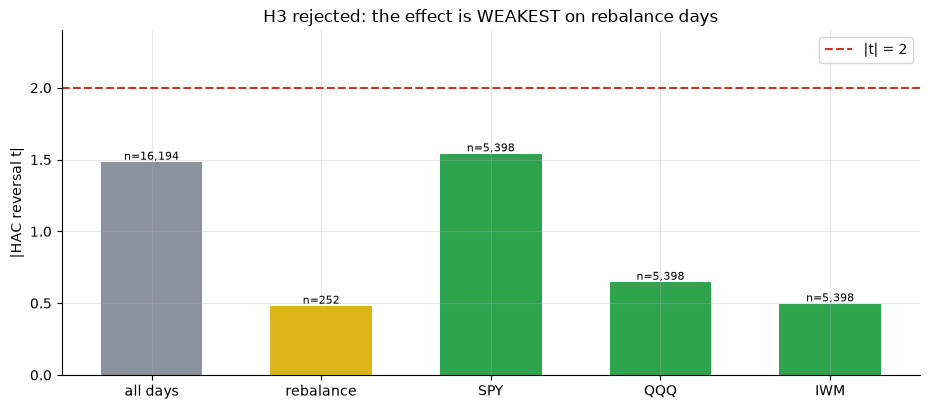

  all days: n=16,194 b=-0.00017 t=-1.48 p=0.076
 rebalance: n=   252 b=-0.00044 t=-0.48 p=0.325
       SPY: n= 5,398 b=-0.00027 t=-1.54 p=0.072
       QQQ: n= 5,398 b=-0.00012 t=-0.64 p=0.266
       IWM: n= 5,398 b=-0.00011 t=-0.49 p=0.316


In [4]:
rows = []
if HAVE_REAL:
    rows.append(('all days', *(lambda s:(s['n'],s['b'],s['t'],s['p_placebo']))(st.summarize(PANEL))))
    rows.append(('rebalance', *(lambda s:(s['n'],s['b'],s['t'],s['p_placebo']))(st.summarize(st.subset(PANEL, rebal_only=True)))))
    for tk in ('SPY','QQQ','IWM'):
        s = st.summarize(PANEL[PANEL['ticker']==tk]); rows.append((tk, s['n'], s['b'], s['t'], s['p_placebo']))
else:
    for k in ('all','rebal','spy','qqq','iwm'):
        n,b,t,p,_,_ = R[k]; rows.append((k, n, b, t, p))
labels = [r[0] for r in rows]; tt = [abs(r[3]) for r in rows]
cols = [GREY, AMBER, GREEN, GREEN, GREEN]
fig, ax = plt.subplots(figsize=(9.4, 4.2))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(2, ls='--', c=RED, label='|t| = 2')
for i,(r,t) in enumerate(zip(rows,tt)): ax.annotate(f'n={r[1]:,}',(i,t),ha='center',va='bottom',fontsize=8)
ax.set_ylabel('|HAC reversal t|'); ax.set_ylim(0,2.4)
ax.set_title('H3 rejected: the effect is WEAKEST on rebalance days'); ax.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:>10}: n={r[1]:>6,} b={r[2]:+.5f} t={r[3]:+.2f} p={r[4]:.3f}')

> 💡 In plain words: on the days a real MOC imbalance is *largest*, the reversal *t* falls to **-0.48** (p = 0.33). A true imbalance-driven dislocation would **concentrate** there. The fact that it *dilutes* there is strong evidence the full-sample lean is generic short-horizon microstructure, not the auction mechanism the story invokes.

### 4d · Costs — the spread is the whole game

The fade's gross edge against the cost of harvesting it. Even gross the per-trade number is sub-basis-point; one crossing of the spread erases it.

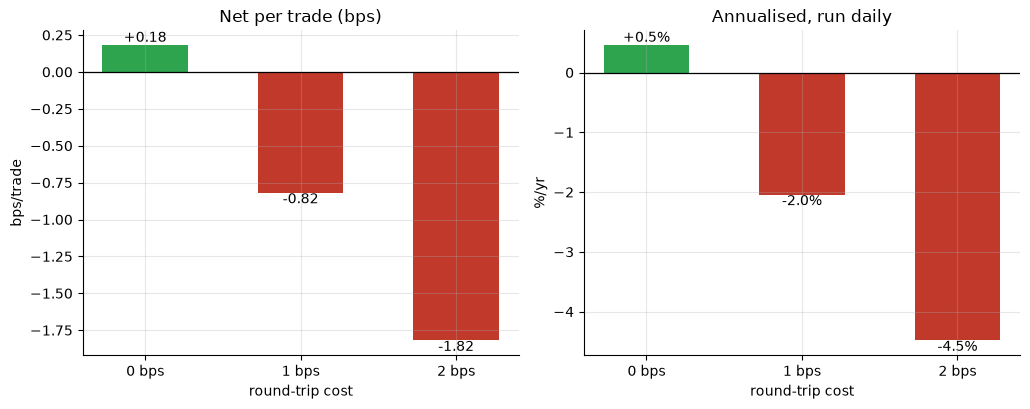

gross +0.18 bps/trade; net @1bp -0.82; @2bp -1.82 (-4.5%/yr)


In [5]:
costs = [0.0, 1.0, 2.0]
if HAVE_REAL:
    res = [st.net_of_costs(PANEL, cb) for cb in costs]
    gross = res[0]['gross_mean']*1e4; nets = [r['net_mean']*1e4 for r in res]; anns = [r['net_ann']*100 for r in res]
else:
    gross = R['costs'][0][1]; nets = [c[1] for c in R['costs']]; anns = [c[2] for c in R['costs']]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.4,4.2))
cols = [GREEN if v>0 else RED for v in nets]
a1.bar([f'{c:.0f} bps' for c in costs], nets, color=cols, width=.55); a1.axhline(0,c='k',lw=.9)
for i,v in enumerate(nets): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a1.set_title('Net per trade (bps)'); a1.set_xlabel('round-trip cost'); a1.set_ylabel('bps/trade')
a2.bar([f'{c:.0f} bps' for c in costs], anns, color=cols, width=.55); a2.axhline(0,c='k',lw=.9)
for i,v in enumerate(anns): a2.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.set_title('Annualised, run daily'); a2.set_xlabel('round-trip cost'); a2.set_ylabel('%/yr')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f} bps/trade; net @1bp {nets[1]:+.2f}; @2bp {nets[2]:+.2f} ({anns[2]:+.1f}%/yr)')

> 💡 In plain words: gross **+0.18 bps** with a daily Sharpe of **~0.04**. A **1-bp** round-trip — optimistic for a close-to-open fade — flips it to **-0.82 bps**; 2 bps gives **-4.5%/yr**. There is no cost assumption under which this is positive at scale. **The reversal is the liquidity provider's spread; the fader is the liquidity taker who pays it.**

### 4e · Faithful-engine & power control — we know the truth here

A deterministic panel with a **planted overnight-reversal knob**: with the knob at **0** the test must stay insignificant (no false positive); with a large knob it must light up. Both hold — so the real-tape t = −1.5 is not a power failure, it is a near-zero true effect.

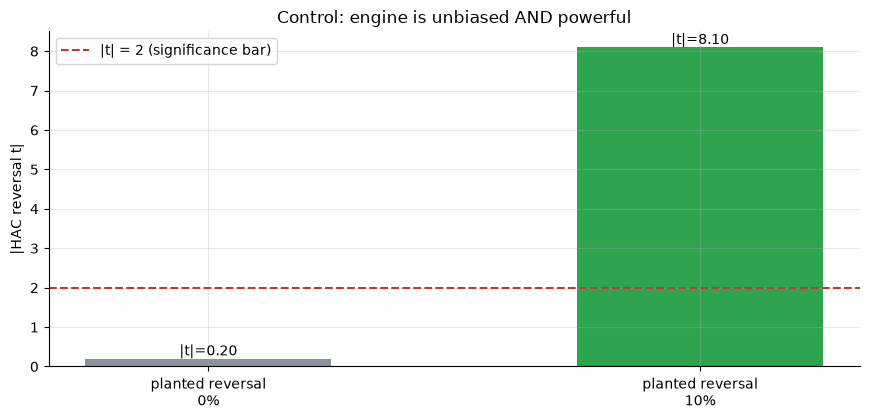

planted    0%: detected n=4000 b=-0.00003 corr=-0.003 t=-0.20 p=0.4155
planted   10%: detected n=4000 b=-0.00111 corr=-0.130 t=-8.10 p=0.0000


In [6]:
res = []
for rev in (0.0, 0.10):
    syn = data.synthetic_panel(reversal=rev, seed=376); s = st.summarize(syn)
    res.append((rev, s['n'], s['b'], s['corr'], s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted reversal\n{r*100:.0f}%' for r,_,_,_,_,_ in res]
tvals = [abs(r[4]) for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='|t| = 2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f'|t|={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('|HAC reversal t|'); ax.set_title('Control: engine is unbiased AND powerful'); ax.legend()
plt.tight_layout(); plt.show()
for r in res: print(f'planted {r[0]*100:>4.0f}%: detected n={r[1]} b={r[2]:+.5f} corr={r[3]:+.3f} t={r[4]:+.2f} p={r[5]:.4f}')

> 💡 In plain words: with **no** planted reversal the control sits at **|t| = 0.20** (no false positive); a **10%** planted reversal reaches **|t| = 8.1** (p < 0.001). The machine is honest and *well-powered* — so the real-tape **t = −1.5** is exactly what an *almost-absent* reversal looks like through a faithful lens. The verdict is the magnitude, not a lack of data.

## 5 · The verdict

- **Signal `WEAK`** — slope **-0.00017** at HAC **t = -1.48** / placebo **p = 0.076**; R² ≈ 0.01%; rebalance-day *t* = -0.48 (H₃ rejected). Direction-correct but **fails t ≥ 2** on the real tape, on a proxy that can only *over*-state the effect ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — gross **+0.18 bps**/trade (Sharpe ≈ 0.04); negative after **1 bp**, **-4.5%/yr** at 2 bps. The reversal lives inside the bid-ask spread — captured by liquidity providers, paid by takers.
- **Free lunch? `BUSTED`** — win-rate **50.5%** ≈ 50%, and the effect *fades* on rebalance days. Real-as-microstructure, empty-as-alpha — the [Amihud](../140-amihud-illiquidity/) pattern: in the data, gone in the trade.

## 6 · Could you trade it? — the break-even spread

The operational truth in one picture: how small would the round-trip cost have to be for the fade to break even? Plot net return vs assumed spread; the break-even is a fraction of a basis point — below any real close-to-open execution.

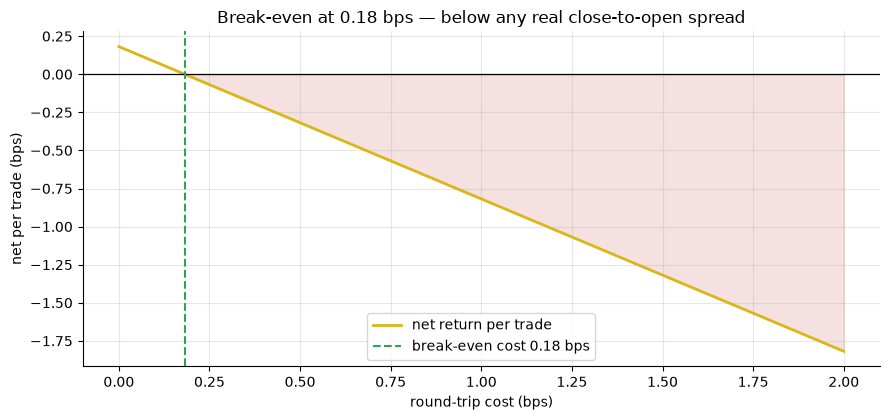

break-even round-trip cost ~ 0.18 bps; realistic close-to-open spread >= 1-2 bps -> always net negative


In [7]:
if HAVE_REAL:
    gross = st.net_of_costs(PANEL, 0.0)['gross_mean']
else:
    gross = R['costs'][0][1]/1e4
cb = np.linspace(0, 2.0, 100)
net = (gross - cb/1e4)*1e4
be = gross*1e4
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(cb, net, c=AMBER, lw=2, label='net return per trade')
ax.axhline(0, c='k', lw=.9); ax.axvline(be, c=GREEN, ls='--', label=f'break-even cost {be:.2f} bps')
ax.fill_between(cb, net, 0, where=(net<0), color=RED, alpha=.15)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net per trade (bps)')
ax.set_title(f'Break-even at {be:.2f} bps — below any real close-to-open spread'); ax.legend()
plt.tight_layout(); plt.show()
print(f'break-even round-trip cost ~ {be:.2f} bps; realistic close-to-open spread >= 1-2 bps -> always net negative')

> 💡 In plain words: the fade breaks even only if you can round-trip for under **~0.2 bps** — less than the bid-ask spread of even SPY at the close, let alone IWM. There is no sizing, no venue, no execution that makes a sub-spread edge tradable. **The rarity-free version of this trade is simply: the overnight reversal *is* the market-maker's compensation, and the fader is paying it.** A 'free lunch' that is exactly priced as the cost of lunch.

## 7 · Going further

- **The decomposition.** [Study 01 — Overnight-Anomaly](../01-overnight-anomaly/): where equity returns are earned, overnight vs intraday. The MOC-reversal trade is a microstructure slice of that split.
- **The archetype.** [Study 140 — Amihud-Illiquidity](../140-amihud-illiquidity/) — an effect that is genuinely in the data yet lives inside frictions, so the trade pays it back. Reading the two together is the cleanest demonstration that *being in the data* and *being tradable* are different claims.
- **Real imbalance data.** Swap the displacement proxy for a true NYSE/Nasdaq MOC imbalance feed and re-run the regression and the fade net of costs; the proxy can only *over*-state the reversal, so a sub-spread proxy edge bounds the real one from above.

*The reproducible core is offline and deterministic; the closing-pressure input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*